In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

Baris kode di atas merupakan bagian untuk meng-import library yang dibutuhkan. Library numpy di-import dengan alias np dan digunakan untuk melakukan operasi matematis pada array multidimensi yang merepresentasikan piksel gambar. Library matplotlib.pyplot di-import dengan alias plt dan digunakan untuk menampilkan gambar maupun grafik histogram secara visual. Library cv2 di-import dan digunakan khusus untuk membaca file gambar dari disk serta mengubahnya ke format grayscale.

Gambar robby_negatif dibaca menggunakan plt sehingga hasil citranya dalam format RGB seperti yang ditampilkan pada gambar di bawah ini. Gambarnya masih aneh dan tidak enak dilihat sehingga perlu dilakukan beberapa operasi citra.

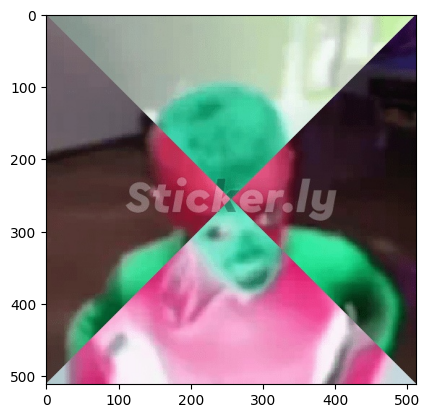

In [2]:
robby = plt.imread("Assets/robby_negatif.jpg")
plt.imshow(robby)

In [3]:
def diagonal_bawah(image):
    height, width = image.shape[:2]
    
    bawah = np.zeros_like(image)
    atas = np.zeros_like(image)

    for i in range(height):
        for j in range(width):
            if i >= j:
                bawah[i, j, :] = image[i, j, :]
            else:
                atas[i, j, :] = image[i, j, :]
                
    return bawah

Fungsi diagonal_bawah(image) digunakan untuk memisahkan bagian citra berdasarkan garis diagonal utama matriks gambar. Pada awal fungsi, ukuran gambar diambil menggunakan image.shape[:2] yang menghasilkan nilai height (tinggi) dan width (lebar). Setelah itu dibuat dua buah array kosong, yaitu bawah dan atas, menggunakan np.zeros_like(image). Kedua array ini memiliki ukuran dan tipe data yang sama dengan gambar asli, tetapi seluruh pikselnya diinisialisasi bernilai 0 atau hitam.

Selanjutnya, fungsi melakukan perulangan bersarang (for i dan for j) untuk memeriksa setiap piksel pada gambar. Kondisi if i >= j digunakan untuk menentukan apakah posisi piksel berada di area diagonal bawah atau tepat pada diagonal utama. Jika kondisi tersebut terpenuhi, maka nilai piksel dari gambar asli akan disalin ke array bawah pada posisi yang sama. Sebaliknya, jika posisi piksel berada di atas diagonal utama (i < j), maka piksel tersebut disalin ke array atas.

Namun, pada akhir fungsi hanya array bawah yang dikembalikan menggunakan return bawah. Hal ini berarti hasil akhir fungsi adalah citra yang hanya menampilkan bagian bawah diagonal dari gambar asli, sedangkan bagian atas diagonal akan tetap berwarna hitam karena tidak diisi nilai piksel.

In [4]:
def diagonal_atas(image):
    height, width = image.shape[:2]
    
    bawah = np.zeros_like(image)
    atas = np.zeros_like(image)

    for i in range(height):
        for j in range(width):
            if i >= j:
                bawah[i, j, :] = image[i, j, :]
            else:
                atas[i, j, :] = image[i, j, :]
                
    return atas

Fungsi diagonal_atas(image) digunakan untuk mengambil bagian citra yang berada di atas garis diagonal utama suatu gambar. Pada bagian awal, fungsi memperoleh ukuran gambar melalui image.shape[:2], di mana height menyimpan tinggi gambar dan width menyimpan lebarnya. Setelah itu dibuat dua array kosong bernama bawah dan atas menggunakan np.zeros_like(image). Kedua array tersebut memiliki ukuran yang sama dengan gambar asli, tetapi seluruh pikselnya bernilai nol sehingga tampak hitam.

Berikutnya, fungsi melakukan iterasi pada setiap piksel gambar menggunakan perulangan bersarang for i dan for j. Kondisi if i >= j digunakan untuk menentukan posisi piksel terhadap diagonal utama. Jika kondisi bernilai benar, piksel disimpan ke array bawah, yang berarti piksel tersebut berada di area diagonal bawah atau tepat pada garis diagonal. Sebaliknya, jika i < j, maka piksel dianggap berada di area diagonal atas sehingga nilainya disalin ke array atas.

Pada akhir fungsi, yang dikembalikan adalah return atas. Oleh karena itu, hasil akhir fungsi berupa gambar yang hanya menampilkan bagian atas diagonal dari citra asli, sedangkan area bawah diagonal akan tetap hitam karena tidak diisi piksel.

Kode di bawah ini digunakan untuk memotong citra berdasarkan diagonal citra. Pertama-tama, citra asli dipotong berdasarkan diagonal utama. Hasil pemotongan berdasarkan diagonal ditampilkan pada dua buah citra di bawah ini.

Pada baris pertama, fungsi diagonal_bawah(robby) dipanggil untuk mengambil bagian gambar yang berada di bawah garis diagonal utama, lalu hasilnya disimpan ke dalam variabel robby_d1. Setelah itu, fungsi diagonal_atas(robby) digunakan untuk mengambil bagian gambar yang berada di atas diagonal utama, dan hasilnya disimpan pada variabel robby_d2.

Selanjutnya, fungsi plt.subplot(1,2,1) digunakan untuk membuat area tampilan subplot dengan susunan 1 baris dan 2 kolom, lalu memilih posisi pertama untuk menampilkan gambar. Perintah plt.imshow(robby_d1) kemudian menampilkan hasil citra bagian diagonal bawah. Setelah itu, plt.subplot(1,2,2) memilih posisi kedua pada subplot sehingga gambar berikutnya dapat ditampilkan berdampingan dengan gambar pertama. Perintah plt.imshow(robby_d2) digunakan untuk menampilkan hasil citra bagian diagonal atas.

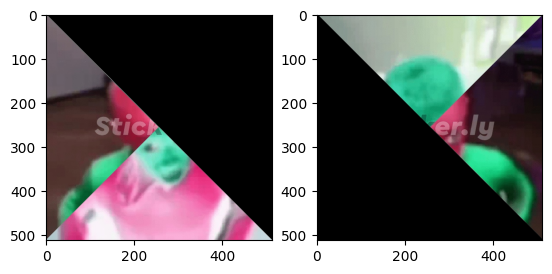

In [5]:
robby_d1 = diagonal_bawah(robby)
robby_d2 = diagonal_atas(robby)

plt.subplot(1,2,1)
plt.imshow(robby_d1)

plt.subplot(1,2,2)
plt.imshow(robby_d2)

In [6]:
def rotasi_rgb(image, derajat):
   
    h, w = image.shape[:2]
    sudut = np.radians(derajat)

    cx, cy = w / 2, h / 2

    
    hasil = np.zeros_like(image)

    for i in range(h):
        for j in range(w):
            
            x = (j - cx) * np.cos(-sudut) - (i - cy) * np.sin(-sudut) + cx
            y = (j - cx) * np.sin(-sudut) + (i - cy) * np.cos(-sudut) + cy

            x, y = int(round(x)), int(round(y))

            
            if 0 <= x < w and 0 <= y < h:
        
                hasil[i, j] = image[y, x]

    return hasil

Fungsi rotasi_rgb(image, derajat) digunakan untuk melakukan rotasi pada citra berwarna (RGB) berdasarkan sudut tertentu secara manual. Pada awal fungsi, ukuran gambar diambil menggunakan image.shape[:2], sehingga diperoleh tinggi (h) dan lebar (w) gambar. Nilai sudut rotasi yang diberikan dalam satuan derajat kemudian dikonversi menjadi radian menggunakan np.radians(derajat) karena fungsi trigonometri pada NumPy bekerja dalam satuan radian. Setelah itu, titik pusat gambar dihitung melalui cx dan cy, yang digunakan sebagai pusat rotasi agar gambar berputar terhadap titik tengahnya.

Selanjutnya, dibuat array kosong bernama hasil menggunakan np.zeros_like(image) untuk menyimpan citra hasil rotasi. Fungsi kemudian melakukan iterasi pada setiap koordinat piksel gambar menggunakan perulangan bersarang for i dan for j. Untuk setiap piksel pada gambar hasil, dihitung posisi koordinat asalnya pada gambar input menggunakan rumus transformasi rotasi. Perhitungan tersebut memanfaatkan fungsi sinus dan cosinus dengan sudut negatif (-sudut) untuk melakukan inverse mapping, yaitu mencari posisi piksel sumber dari gambar asli agar tidak terjadi lubang kosong pada hasil rotasi.

Koordinat hasil perhitungan kemudian dibulatkan menggunakan round() dan diubah menjadi bilangan bulat dengan int(), karena indeks array harus berupa integer. Setelah itu dilakukan pengecekan apakah koordinat (x, y) masih berada dalam batas ukuran gambar. Jika valid, maka nilai piksel pada posisi tersebut diambil dari gambar asli image[y, x] dan disimpan ke posisi yang sesuai pada array hasil. Terakhir, fungsi mengembalikan gambar hasil rotasi melalui return hasil.

Kode di bawah ini digunakan untuk memutar dua citra hasil pemisahan diagonal menggunakan fungsi rotasi_rgb(), kemudian menampilkan hasil rotasinya dengan Matplotlib. Pada baris pertama, variabel robby_d1, yang sebelumnya berisi bagian bawah diagonal dari gambar robby, diputar sebesar 90 derajat menggunakan fungsi rotasi_rgb(robby_d1, 90). Hasil rotasi tersebut disimpan ke dalam variabel robby_d1_rot. Proses yang sama juga dilakukan pada robby_d2, yaitu citra bagian atas diagonal, dan hasilnya disimpan pada variabel robby_d2_rot.

Tujuan dilakukannya rotasi karena fungsi diagonal_bawah dan diagonal_atas hanya bisa beroperasi untuk diagonal utama sehingga harus dirotasi dulu supaya ketika dilakukan pemotongan diagonal, diagonal utamanya yang kena potong.

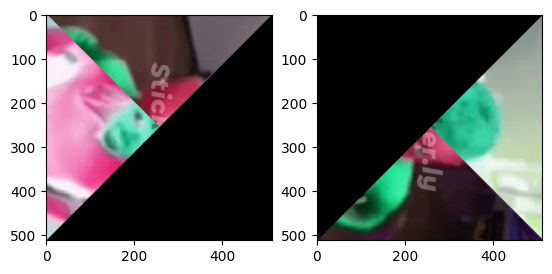

In [7]:
robby_d1_rot = rotasi_rgb(robby_d1, 90)
robby_d2_rot = rotasi_rgb(robby_d2, 90)

plt.subplot(1,2,1)
plt.imshow(robby_d1_rot)
plt.subplot(1,2,2)
plt.imshow(robby_d2_rot)

Kode di bawah ini digunakan untuk melakukan pemisahan ulang citra berdasarkan diagonal utama setelah gambar sebelumnya mengalami proses rotasi. Pada baris pertama dan kedua, gambar robby_d1_rot yang merupakan hasil rotasi bagian bawah diagonal diproses kembali menggunakan fungsi diagonal_atas() dan diagonal_bawah(). Hasil bagian atas diagonal disimpan dalam variabel robby_d3, sedangkan bagian bawah diagonalnya disimpan dalam robby_d4. Proses yang sama juga diterapkan pada robby_d2_rot, yaitu hasil rotasi bagian atas diagonal sebelumnya. Fungsi diagonal_atas() menghasilkan robby_d5, sedangkan diagonal_bawah() menghasilkan robby_d6.

Dengan demikian, didapatkan empat potongan citra seperti pada gambar di bawah ini.

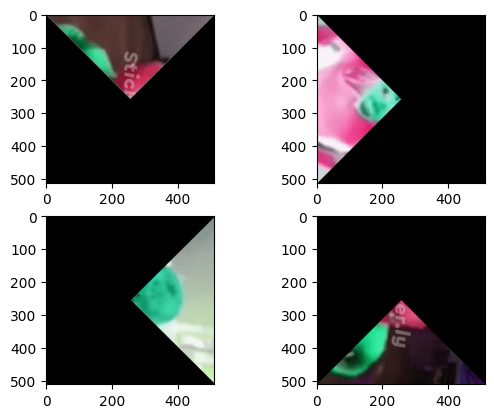

In [8]:
robby_d3 = diagonal_atas(robby_d1_rot)
robby_d4 = diagonal_bawah(robby_d1_rot)
robby_d5 = diagonal_atas(robby_d2_rot)
robby_d6 = diagonal_bawah(robby_d2_rot)

plt.subplot(2,2,1)
plt.imshow(robby_d3)
plt.subplot(2,2,2)
plt.imshow(robby_d4)
plt.subplot(2,2,3)
plt.imshow(robby_d5)
plt.subplot(2,2,4)
plt.imshow(robby_d6)

Kode di bawah ini digunakan untuk membuat efek citra negatif (negative image) pada dua gambar, yaitu robby_d4 dan robby_d5 sehingga didapatkan hasil seperti citra di bawah ini.

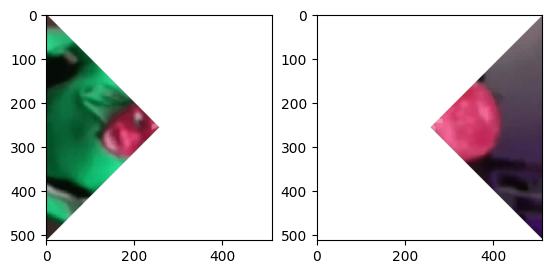

In [9]:
d4_negatif = 255 - robby_d4
d5_negatif = 255 - robby_d5

plt.subplot(1,2,1)
plt.imshow(d4_negatif)
plt.subplot(1,2,2)
plt.imshow(d5_negatif)


Ini buat nampilin semuanya aja sih.

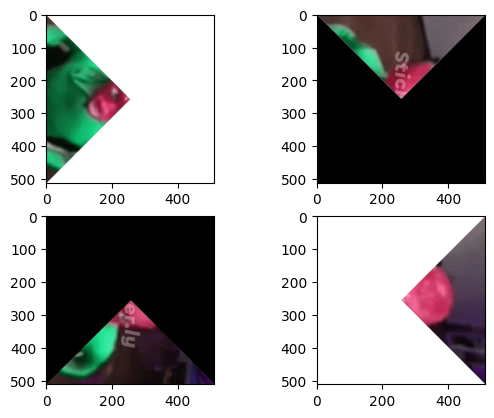

In [10]:
plt.subplot(2,2,1)
plt.imshow(d4_negatif)
plt.subplot(2,2,2)
plt.imshow(robby_d3)
plt.subplot(2,2,3)
plt.imshow(robby_d6)
plt.subplot(2,2,4)
plt.imshow(d5_negatif)

Oleh karena ukuran piksel keempat potongan gambar sama semua dan harus dilakukan penggabungan citra supaya menjadi satu citra utuh maka dilakukan penjumlahan matriks sehingga diperoleh citra utuh seperti pada gambar di bawah ini.

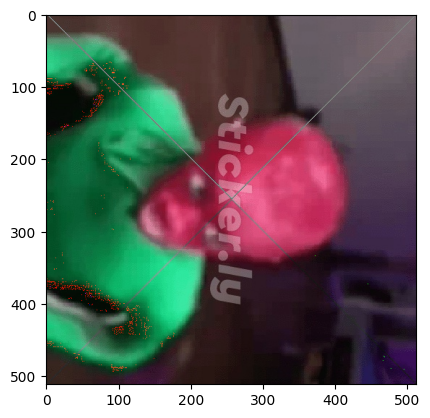

In [11]:
jumlah = d5_negatif + robby_d3 + robby_d6 + d4_negatif
plt.imshow(jumlah)

In [12]:
def normalize_min_max_rgb(image):
    # Mengambil nilai min dan max dari seluruh array (global)
    min_val = np.min(image)
    max_val = np.max(image)
    
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8)
    
    # Konversi ke float agar perhitungan (image - min) tidak error/wrap-around
    # Lalu lakukan normalisasi rumus: (x - min) / (max - min)
    norm = (image.astype(np.float32) - min_val) / (max_val - min_val)
    
    # Kembalikan ke rentang 0-255 dan tipe uint8
    return (norm * 255).astype(np.uint8)

Fungsi normalize_min_max_rgb(image) digunakan untuk melakukan normalisasi intensitas pada citra RGB menggunakan metode Min-Max Normalization. Tujuan dari proses ini adalah mengubah rentang nilai piksel gambar agar tersebar kembali dari 0 hingga 255 sehingga kontras citra dapat menjadi lebih optimal. Pada awal fungsi, nilai intensitas minimum dan maksimum dari seluruh piksel gambar dicari menggunakan np.min(image) dan np.max(image). Nilai tersebut digunakan sebagai acuan dalam proses normalisasi.

Selanjutnya, fungsi memeriksa kondisi if max_val == min_val. Kondisi ini dilakukan untuk menghindari pembagian dengan nol yang dapat terjadi apabila seluruh piksel memiliki nilai yang sama. Jika kondisi tersebut terpenuhi, fungsi akan mengembalikan array kosong berisi nol dengan ukuran yang sama seperti gambar asli menggunakan np.zeros_like(image, dtype=np.uint8).

Jika nilai minimum dan maksimum berbeda, maka gambar terlebih dahulu dikonversi ke tipe data float32 menggunakan image.astype(np.float32). Konversi ini penting agar operasi pengurangan dan pembagian dapat dilakukan dengan presisi desimal serta menghindari kesalahan overflow atau wrap-around pada tipe data uint8. Setelah itu dilakukan normalisasi menggunakan rumus Min-Max

In [13]:
def histogram_equalization_rgb(image):
    # 1. Ambil dimensi (Tinggi, Lebar, Saluran)
    height, width, channels = image.shape
    
    # Siapkan array kosong untuk hasil akhir
    result_image = np.zeros_like(image, dtype=np.uint8)

    # 2. Lakukan iterasi untuk setiap channel (0: Red, 1: Green, 2: Blue)
    for c in range(channels):
        # --- Proses Histogram ---
        hist = np.zeros(256, dtype=int)
        for i in range(height):
            for j in range(width):
                val = image[i, j, c]
                hist[val] += 1

        # --- Proses CDF (Cumulative Distribution Function) ---
        cdf = np.zeros(256, dtype=int)
        cumulative_sum = 0
        for i in range(256):
            cumulative_sum += hist[i]
            cdf[i] = cumulative_sum

        # --- Proses Mapping (Normalisasi CDF ke 0-255) ---
        # Rumus: (cdf(i) * 255) / total_piksel
        lookup_table = np.round((cdf * 255) / (height * width)).astype(np.uint8)

        # --- Terapkan ke Citra ---
        for i in range(height):
            for j in range(width):
                original_val = image[i, j, c]
                result_image[i, j, c] = lookup_table[original_val]

    return result_image

Fungsi histogram_equalization_rgb(image) digunakan untuk meningkatkan kualitas kontras citra RGB dengan metode histogram equalization. Teknik ini bekerja dengan menyebarkan distribusi intensitas piksel agar lebih merata sehingga detail pada gambar menjadi lebih jelas. Pada awal fungsi, ukuran gambar diambil menggunakan image.shape, yang menghasilkan nilai tinggi (height), lebar (width), dan jumlah saluran warna (channels). Setelah itu dibuat array kosong bernama result_image menggunakan np.zeros_like(image, dtype=np.uint8) untuk menyimpan hasil akhir proses histogram equalization.

Selanjutnya, fungsi melakukan iterasi pada setiap channel warna gambar, yaitu merah (Red), hijau (Green), dan biru (Blue). Pada setiap channel, proses pertama adalah menghitung histogram intensitas piksel. Array hist berukuran 256 dibuat untuk merepresentasikan jumlah kemunculan setiap nilai intensitas dari 0 hingga 255. Melalui perulangan bersarang, setiap piksel pada channel tertentu diperiksa dan jumlah kemunculan nilai intensitasnya ditambahkan ke histogram.

Setelah histogram diperoleh, fungsi menghitung Cumulative Distribution Function (CDF) menggunakan array cdf. CDF merupakan jumlah kumulatif dari histogram yang menunjukkan distribusi akumulatif intensitas piksel. Perhitungan dilakukan dengan menjumlahkan nilai histogram secara bertahap dari intensitas terkecil hingga terbesar. Nilai CDF ini kemudian digunakan untuk membuat lookup_table, yaitu tabel pemetaan intensitas baru. Tabel tersebut diperoleh dengan menormalisasi nilai CDF ke rentang 0–255 menggunakan rumus.

Hasil normalisasi dibulatkan menggunakan np.round() lalu dikonversi menjadi tipe uint8.

Tahap terakhir adalah menerapkan tabel pemetaan tersebut ke citra asli. Setiap piksel pada channel tertentu diambil nilainya, kemudian diganti dengan nilai baru berdasarkan lookup_table. Nilai baru tersebut disimpan ke dalam result_image. Proses ini dilakukan untuk seluruh channel warna sehingga menghasilkan citra RGB dengan distribusi intensitas yang lebih merata.

In [14]:
def equalization_channel(channel):

    height, width = channel.shape

    # Membuat histogram
    hist = np.zeros(256, dtype=int)

    for i in range(height):
        for j in range(width):
            val = channel[i, j]
            hist[val] += 1

    # Menghitung CDF
    cdf = np.zeros(256, dtype=int)
    cumulative = 0

    for i in range(256):
        cumulative += hist[i]
        cdf[i] = cumulative

    # Normalisasi CDF menjadi lookup table
    lookup = np.round((cdf * 255) / (height * width)).astype(np.uint8)

    # Membuat hasil channel baru
    result = np.zeros_like(channel)

    for i in range(height):
        for j in range(width):
            result[i, j] = lookup[channel[i, j]]

    return result


def histogram_equalization_channel(image):

    # Pisahkan channel RGB
    r = image[:, :, 0]
    g = image[:, :, 1]
    b = image[:, :, 2]

    # Equalization tiap channel
    r_eq = equalization_channel(r)
    g_eq = equalization_channel(g)
    b_eq = equalization_channel(b)

    # Gabungkan kembali
    result = np.zeros_like(image)

    result[:, :, 0] = r_eq
    result[:, :, 1] = g_eq
    result[:, :, 2] = b_eq

    return result

Fungsi equalization_channel(channel) digunakan untuk melakukan histogram equalization pada satu channel citra grayscale secara manual. Fungsi pertama-tama menghitung histogram intensitas piksel, kemudian membentuk Cumulative Distribution Function (CDF) untuk mengetahui distribusi kumulatif intensitas. Nilai CDF tersebut dinormalisasi menjadi lookup table dengan rentang 0–255, lalu setiap piksel pada channel diganti berdasarkan tabel pemetaan tersebut. Hasil akhirnya adalah channel dengan kontras yang lebih merata.

Sementara itu, fungsi histogram_equalization_channel(image) digunakan untuk menerapkan histogram equalization pada citra RGB. Fungsi memisahkan gambar menjadi tiga channel warna, yaitu merah (R), hijau (G), dan biru (B), kemudian masing-masing channel diproses menggunakan fungsi equalization_channel(). Setelah proses selesai, ketiga channel hasil ekualisasi digabung kembali menjadi satu citra RGB baru. Hasil akhirnya adalah gambar berwarna dengan kontras yang meningkat pada setiap channel warna.

Kode di bawah ini digunakan untuk melakukan rotasi citra dan meningkatkan kontras gambar menggunakan histogram equalization per channel warna. Pada baris pertama, gambar jumlah diputar sebesar -90 derajat menggunakan fungsi rotasi_rgb(), kemudian hasilnya disimpan dalam variabel sebelum. Setelah itu, citra hasil rotasi diproses menggunakan fungsi histogram_equalization_channel() untuk melakukan ekualisasi histogram pada setiap channel warna RGB, dan hasilnya disimpan dalam variabel sesudah.

Selanjutnya, kedua gambar ditampilkan menggunakan Matplotlib dengan susunan subplot 1 baris dan 2 kolom. Gambar pertama menampilkan citra sebelum proses ekualisasi, sedangkan gambar kedua menampilkan hasil setelah histogram equalization diterapkan.

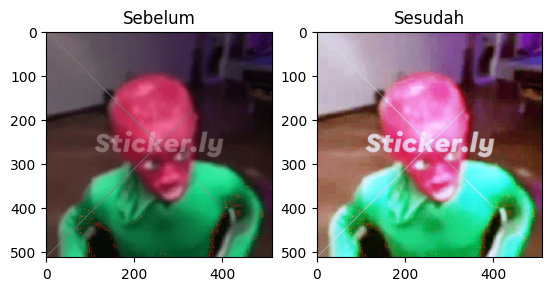

In [15]:
sebelum = rotasi_rgb(jumlah, -90)
sesudah = histogram_equalization_channel(sebelum)

plt.subplot(1,2,1)
plt.title("Sebelum")
plt.imshow(sebelum)
plt.subplot(1,2,2)
plt.title("Sesudah")
plt.imshow(sesudah)

In [16]:
def buat_hist_rgb(citra): 
    # Inisialisasi 3 histogram untuk R, G, dan B
    hist_r = [0] * 256 
    hist_g = [0] * 256 
    hist_b = [0] * 256 
 
    height = citra.shape[0] 
    width = citra.shape[1] 

    for i in range(height): 
        for j in range(width): 
            # Ambil nilai R, G, dan B dari koordinat piksel
            r = int(citra[i, j, 0])
            g = int(citra[i, j, 1])
            b = int(citra[i, j, 2])
            
            hist_r[r] += 1
            hist_g[g] += 1
            hist_b[b] += 1
 
    return hist_r, hist_g, hist_b


def plot_histogram_rgb(hists, title): 
    # hists adalah tuple (hist_r, hist_g, hist_b) dari fungsi sebelumnya
    colors = ('red', 'green', 'blue')
    labels = ('Channel Merah', 'Channel Hijau', 'Channel Biru')
    
    plt.figure(figsize=(10, 6)) 
    
    for i in range(3):
        # gunakan alpha=0.4 agar saat warna bertumpuk, perbedaannya terlihat
        # label=labels[i] penting agar legend bisa muncul otomatis
        plt.bar(range(256), hists[i], color=colors[i], width=0.7, alpha=0.4, label=labels[i])

    plt.title(title) 
    plt.xlabel("Intensitas Piksel (0-255)") 
    plt.ylabel("Jumlah Piksel") 
    
    # Menampilkan keterangan (legend) berdasarkan label yang sudah diset di atas
    plt.legend(loc='upper right') 
    
    plt.grid(axis='y', alpha=0.2)
    plt.show()

Fungsi buat_hist_rgb(citra) digunakan untuk menghitung histogram dari citra RGB secara manual. Histogram citra merupakan representasi distribusi jumlah piksel berdasarkan nilai intensitas warna. Pada awal fungsi, dibuat tiga buah array histogram, yaitu hist_r, hist_g, dan hist_b, masing-masing berukuran 256 elemen yang merepresentasikan intensitas warna dari 0 hingga 255 untuk channel merah (Red), hijau (Green), dan biru (Blue). Semua elemen awalnya bernilai 0 karena belum ada perhitungan jumlah piksel.

Selanjutnya, fungsi mengambil ukuran citra menggunakan citra.shape, di mana height menyimpan tinggi gambar dan width menyimpan lebar gambar. Kemudian dilakukan perulangan bersarang untuk memeriksa setiap piksel pada citra. Pada setiap koordinat (i, j), fungsi mengambil nilai intensitas merah, hijau, dan biru menggunakan indeks channel 0, 1, dan 2. Nilai intensitas tersebut kemudian digunakan sebagai indeks array histogram untuk menambah jumlah kemunculan masing-masing warna. Sebagai contoh, jika suatu piksel memiliki nilai merah 120, maka hist_r[120] akan ditambah satu. Proses ini dilakukan untuk seluruh piksel sehingga diperoleh distribusi intensitas lengkap dari ketiga channel warna. Pada akhir fungsi, ketiga histogram dikembalikan dalam bentuk tuple (hist_r, hist_g, hist_b).

Sementara itu, fungsi plot_histogram_rgb(hists, title) digunakan untuk memvisualisasikan histogram RGB yang telah dihitung sebelumnya. Parameter hists berisi tuple histogram merah, hijau, dan biru, sedangkan title digunakan sebagai judul grafik. Fungsi mendefinisikan warna tampilan histogram (red, green, blue) dan label masing-masing channel agar grafik lebih mudah dipahami. Setelah itu dibuat area gambar menggunakan plt.figure(figsize=(10, 6)) dengan ukuran tertentu agar tampilan histogram lebih jelas.

Kemudian dilakukan perulangan sebanyak tiga kali untuk menampilkan histogram setiap channel warna menggunakan plt.bar(). Grafik batang digunakan untuk menunjukkan jumlah piksel pada setiap intensitas warna dari 0 hingga 255. Parameter alpha=0.4 memberikan efek transparansi sehingga ketika histogram warna saling bertumpuk, perbedaannya masih dapat terlihat. Label yang diberikan pada setiap histogram memungkinkan fungsi plt.legend() menampilkan keterangan channel warna secara otomatis di bagian kanan atas grafik.

Terakhir, fungsi menambahkan judul grafik, label sumbu X dan Y, serta grid horizontal untuk mempermudah pembacaan distribusi data. Fungsi plt.show() digunakan untuk menampilkan histogram ke layar.

Kode di bawah ini digunakan untuk melakukan peningkatan kualitas citra dan menganalisis perubahan distribusi intensitas warna melalui histogram RGB. Pada awal proses, gambar sebelum dinormalisasi menggunakan fungsi normalize_min_max_rgb() agar rentang intensitas piksel menjadi lebih merata, kemudian hasilnya disimpan dalam variabel sebelum_norm. Setelah itu, citra hasil normalisasi diproses menggunakan histogram_equalization_rgb() untuk meningkatkan kontras pada setiap channel warna RGB, dan hasilnya disimpan dalam sebelum_ekual.

Selanjutnya, histogram RGB dari gambar hasil ekualisasi dihitung menggunakan buat_hist_rgb(sebelum_ekual) dan disimpan dalam sebelum_ekual_hist. Histogram RGB dari gambar asli sebelum juga dihitung dan disimpan dalam sebelum_hist. Kedua histogram tersebut kemudian ditampilkan menggunakan fungsi plot_histogram_rgb(), yaitu histogram gambar sebelum proses peningkatan kontras dan histogram gambar setelah histogram equalization.

Hasil histogram ditampilkan pada gambar di bawah ini

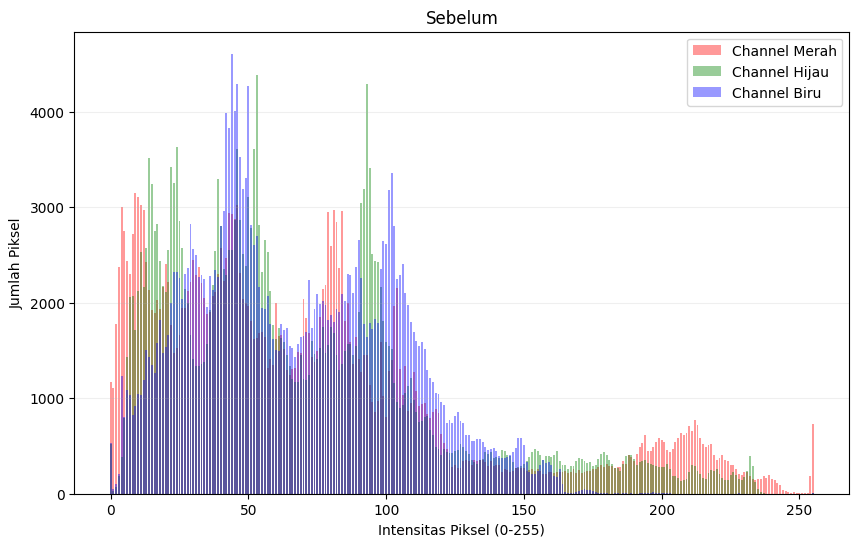

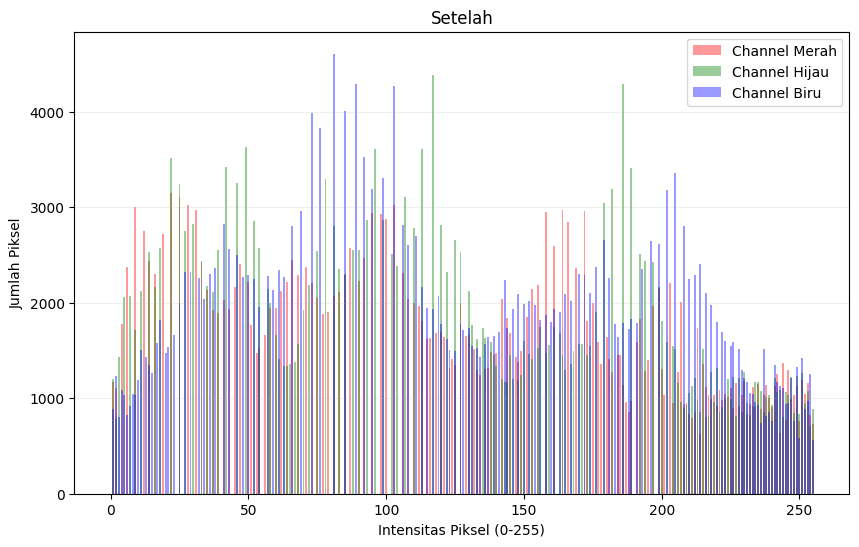

In [17]:
sebelum_norm = normalize_min_max_rgb(sebelum)
sebelum_ekual = histogram_equalization_rgb(sebelum_norm)
sebelum_ekual_hist = buat_hist_rgb(sebelum_ekual)
sebelum_hist = buat_hist_rgb(sebelum)
sebelum_plot = plot_histogram_rgb(sebelum_hist, "Sebelum")
sebelum_ekual_plot = plot_histogram_rgb(sebelum_ekual_hist, "Setelah")

Kode di bawah ini digunakan untuk membaca gambar, mengubah citra berwarna menjadi grayscale, lalu menampilkan hasilnya menggunakan Matplotlib. Pada baris pertama, gambar bahlul.jpg dibaca dari folder Assets menggunakan plt.imread() dan disimpan dalam variabel bahlul. Setelah itu, gambar bahlul dikonversi menjadi citra grayscale menggunakan cv2.cvtColor() dengan parameter cv2.COLOR_BGR2GRAY, sehingga menghasilkan gambar satu channel intensitas abu-abu yang disimpan dalam bahlul_gray. Proses yang sama juga dilakukan pada gambar sebelum, dan hasilnya disimpan dalam variabel sebelum_gray.

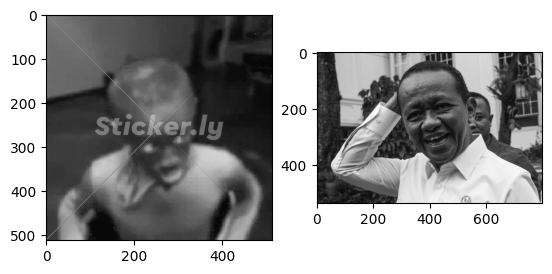

In [18]:
bahlul = plt.imread("Assets/bahlul.jpg")
bahlul_gray = cv2.cvtColor(bahlul, cv2.COLOR_BGR2GRAY)
sebelum_gray = cv2.cvtColor(sebelum, cv2.COLOR_BGR2GRAY)

plt.subplot(1,2,1)
plt.imshow(sebelum_gray, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(bahlul_gray, cmap='gray')

In [19]:
def normalize_min_max(image):
    min_val = np.min(image)
    max_val = np.max(image)
    if max_val == min_val:
        return np.zeros_like(image, dtype=np.uint8) 
    norm = (image - min_val) / (max_val - min_val)
    return (norm * 255).astype(np.uint8)

def histogram_equalization(image):
    e_hist = np.zeros(256, dtype=int)
    height, width = image.shape

    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            e_hist[val] += 1

    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(e_hist[0:i+1])

    result = np.round((cdf * 255) / (height * width)).astype(np.uint8)

    result2 = np.zeros(image.shape, dtype=np.uint8)
    for i in range(height):
        for j in range(width):
            val = int(image[i, j])
            result2[i, j] = result[val]

    return result2

def histogram_specification(source, target):
    height, width = source.shape

    # Hitung histogram source
    hist_source = np.zeros(256, dtype=int)
    for i in range(height):
        for j in range(width):
            hist_source[source[i, j]] += 1
    cdf_source = np.cumsum(hist_source)
    cdf_source = np.round(cdf_source * 255 / cdf_source[-1]).astype(np.uint8)

    # Hitung histogram target
    hist_target = np.zeros(256, dtype=int)
    for i in range(target.shape[0]):
        for j in range(target.shape[1]):
            hist_target[target[i, j]] += 1
    cdf_target = np.cumsum(hist_target)
    cdf_target = np.round(cdf_target * 255 / cdf_target[-1]).astype(np.uint8)

    # Buat mapping dari CDF source ke CDF target
    mapping = np.zeros(256, dtype=np.uint8)
    for source_val in range(256):
        diff = np.abs(cdf_source[source_val] - cdf_target)
        mapping[source_val] = np.argmin(diff)

    # Terapkan mapping ke gambar source
    result = np.zeros_like(source)
    for i in range(height):
        for j in range(width):
            result[i, j] = mapping[source[i, j]]

    return result

Fungsi normalize_min_max(image) digunakan untuk melakukan normalisasi intensitas citra grayscale menggunakan metode Min-Max Normalization. Fungsi mencari nilai minimum dan maksimum piksel, lalu mengubah seluruh nilai piksel ke rentang 0–255 menggunakan rumus normalisasi. Jika semua piksel memiliki nilai yang sama, fungsi akan mengembalikan citra kosong agar tidak terjadi pembagian dengan nol. Hasil akhirnya berupa citra dengan kontras yang lebih merata.

Fungsi histogram_equalization(image) digunakan untuk meningkatkan kontras citra grayscale melalui metode histogram equalization. Fungsi pertama-tama menghitung histogram intensitas piksel, kemudian membuat Cumulative Distribution Function (CDF) untuk mengetahui distribusi kumulatif intensitas. Nilai CDF tersebut dinormalisasi menjadi tabel pemetaan baru yang digunakan untuk mengganti intensitas piksel pada gambar asli. Hasilnya adalah distribusi intensitas yang lebih merata sehingga detail citra menjadi lebih jelas.

Fungsi histogram_specification(source, target) digunakan untuk menyesuaikan distribusi histogram citra sumber agar menyerupai histogram citra target. Fungsi menghitung histogram dan CDF dari kedua gambar, lalu membuat mapping berdasarkan perbedaan nilai CDF yang paling kecil. Setelah mapping terbentuk, setiap piksel pada gambar sumber diganti sesuai tabel pemetaan tersebut. Hasil akhirnya adalah citra sumber dengan karakteristik intensitas yang mendekati citra target.


Kode di bawah ini digunakan untuk melakukan serangkaian proses peningkatan kualitas citra grayscale, yaitu normalisasi, histogram equalization, dan histogram specification. Pada awal proses, gambar grayscale sebelum_gray dinormalisasi menggunakan fungsi normalize_min_max() agar rentang intensitas piksel tersebar lebih merata. Hasilnya disimpan dalam variabel sebelum_gray_norm. Setelah itu, citra hasil normalisasi diproses menggunakan histogram_equalization() untuk meningkatkan kontras gambar melalui penyebaran distribusi intensitas piksel, dan hasilnya disimpan dalam sebelum_gray_ekual.

Selanjutnya, hasil ekualisasi diproses kembali menggunakan fungsi histogram_specification(), dengan gambar bahlul sebagai citra target. Proses ini bertujuan menyesuaikan distribusi histogram citra sumber agar menyerupai histogram citra target. Hasil akhirnya disimpan dalam variabel sebelum_gray_spec.

Tiga buah gambar di bawah ini merupakan perbandingan citra normalisasi, ekualisasi, dan spesifikasi.

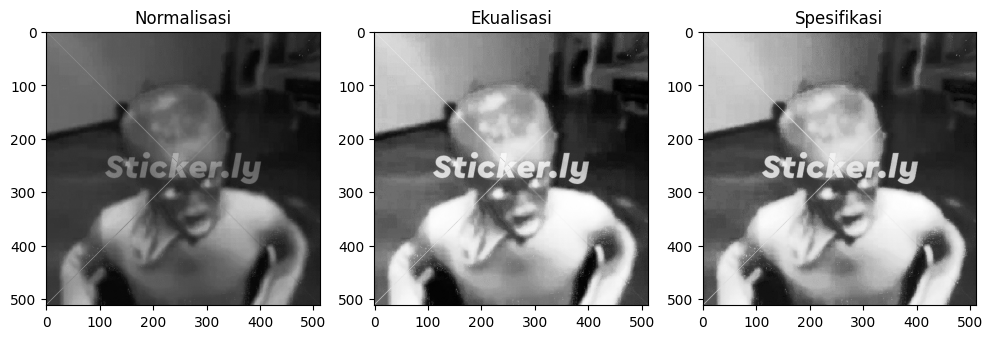

In [20]:
sebelum_gray_norm = normalize_min_max(sebelum_gray)
sebelum_gray_ekual = histogram_equalization(sebelum_gray_norm)
sebelum_gray_spec = histogram_specification(sebelum_gray_ekual, bahlul)

plt.figure(figsize=(12,8))

plt.subplot(1,3,1)
plt.title("Normalisasi")
plt.imshow(sebelum_gray_norm, cmap='gray')
plt.subplot(1,3,2)
plt.title("Ekualisasi")
plt.imshow(sebelum_gray_ekual, cmap='gray')
plt.subplot(1,3,3)
plt.title("Spesifikasi")
plt.imshow(sebelum_gray_spec, cmap='gray')

In [22]:
def buat_hist(citra): 
    histogram = [0] * 256 
 
    height = len(citra) 
    width = len(citra[0]) if height > 0 else 0 
    for i in range(height): 
        for j in range(width): 
            val = int(citra[i][j])   
            histogram[val] += 1   
 
    return histogram 

def plot_histogram(histogram, title, ImgColor): 
    plt.figure(figsize=(10, 5)) 
    plt.xlabel("Intensitas Piksel") 
    plt.title(title) 
    plt.ylabel("Jumlah Piksel") 
    plt.bar(range(256), histogram, color=ImgColor, width=0.8) 
    plt.show() 

Fungsi buat_hist bertugas menghitung frekuensi kemunculan setiap nilai piksel (dari 0 hingga 255) dengan cara menelusuri seluruh baris dan kolom gambar secara manual. Sementara itu, fungsi plot_histogram menggunakan library Matplotlib untuk menampilkan data frekuensi tersebut ke dalam bentuk diagram batang (bar chart).

Kode di bawah ini adalah untuk membuat dan menampilkan histogram hasil spesifikasi

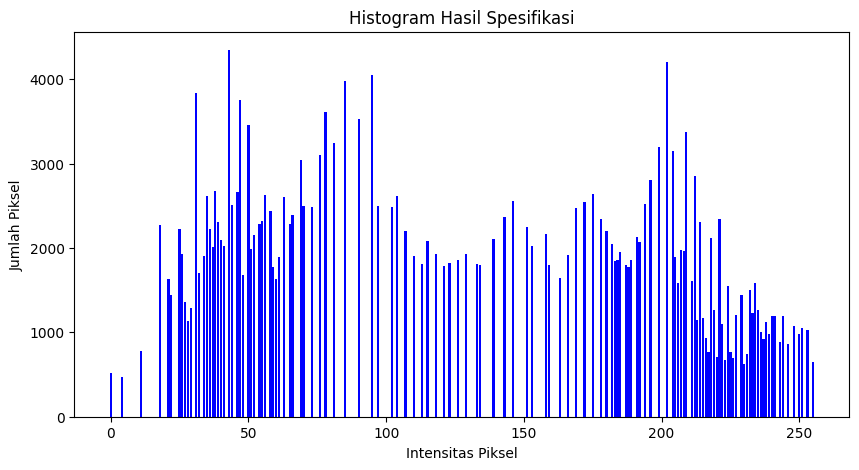

In [23]:
sebelum_gray_hist = buat_hist(sebelum_gray_spec)
sebelum_gray_plot = plot_histogram(sebelum_gray_hist, "Histogram Hasil Spesifikasi", "Blue")

Berdasarkan seluruh rangkaian proses pengolahan citra yang telah dilakukan, dapat disimpulkan bahwa berbagai teknik manipulasi citra digital seperti pemisahan berdasarkan diagonal, rotasi, normalisasi, histogram equalization, histogram specification, serta penggabungan kembali citra memiliki peran penting dalam mengubah dan meningkatkan kualitas visual gambar. Proses pemisahan citra berdasarkan diagonal utama berhasil membagi gambar menjadi dua bagian utama, yaitu bagian atas dan bawah, yang kemudian dapat dianalisis secara terpisah. Selanjutnya, rotasi citra digunakan untuk mengatasi keterbatasan arah pemrosesan diagonal sehingga operasi pemisahan dapat diterapkan kembali secara konsisten pada orientasi yang berbeda.

Pada tahap peningkatan kualitas citra, normalisasi min-max berfungsi untuk menyeimbangkan rentang intensitas piksel agar distribusi warna lebih optimal. Histogram equalization terbukti mampu meningkatkan kontras gambar dengan cara meratakan distribusi intensitas pada setiap channel warna, sehingga detail pada citra menjadi lebih jelas. Sementara itu, histogram specification memberikan hasil yang lebih terarah karena tidak hanya memperbaiki kontras, tetapi juga menyesuaikan karakteristik distribusi intensitas citra sumber agar menyerupai citra referensi.

Selain itu, proses penggabungan kembali hasil potongan citra menunjukkan bahwa operasi matriks dapat digunakan untuk merekonstruksi gambar menjadi satu kesatuan utuh tanpa kehilangan struktur utama. Secara keseluruhan, seluruh tahapan ini menunjukkan bahwa pengolahan citra digital berbasis operasi matriks dan histogram sangat efektif dalam memodifikasi struktur visual, meningkatkan kualitas gambar, serta memungkinkan analisis citra dilakukan secara lebih fleksibel dan terkontrol.